# Libraries


In [1]:
#Used for the first time in "Pathway to save figures"
import os
#Used for the first time in "Import DATA"
import pandas as pd
#Used for the first time in "Principal Component Analyses"
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#Used for the first time in "Hierarchical clustering"
import umap
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from scipy.stats import chi2
from matplotlib.colors import to_hex
from matplotlib.patches import Ellipse
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import set_link_color_palette
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
from itertools import product
import joblib
from scipy.spatial import procrustes
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import warnings
 
#Used for the first time in "Release properties"
import seaborn as sns


#Some module create warnings for futur updates. Here we ignore them. Erase following line to restaure warnings.
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

# Pathway to save figures

In [2]:
output_dir = r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures"
os.makedirs(output_dir, exist_ok=True)

# Import data
The PCA will use only the columns AMP1, AMP2, all PPRs and %Fail1 and 2. All the other columns will be un-selected.

In [3]:
#WT experiments
df_WT_pooled  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime.xlsx', sheet_name="WT_pooled")
df_WT_Theo    = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime.xlsx', sheet_name="WT_Theo")
df_WT_Anthime = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime.xlsx', sheet_name="WT_Anthime")

#SynII experiments
df_SynII      = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime.xlsx', sheet_name="SynII")

#Calcium experiments
df_WT_1_5Ca   = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\GluSnFR_avg_variables_Ca_paired_filtered_3sigma.xlsx', sheet_name=0)
df_WT_4Ca     = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\GluSnFR_avg_variables_Ca_paired_filtered_3sigma.xlsx', sheet_name=1)

In [4]:
#Get rids of the un-used columns for the PCA
df_WT_pooled  = df_WT_pooled.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1) 
df_WT_Theo    = df_WT_Theo.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline', 'Target'], axis=1)
df_WT_Anthime = df_WT_Anthime.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_SynII      = df_SynII.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_WT_1_5Ca   = df_WT_1_5Ca .drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_WT_4Ca     = df_WT_4Ca.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)

#Extracts labels
labels = df_WT_pooled.columns

# Figure 1 : Four classes of STP and glutamate release properties at GC boutons

## 1 - Normalization

Normalization is essential before applying PCA or UMAP because these algorithms are sensitive to the scale of the variables. If features have different units or variances, those with larger scales can dominate the analysis and distort the results. By standardizing all features to have zero mean and unit variance, we ensure that each variable contributes equally to the dimensionality reduction and clustering steps.

In [5]:
#Creates a standard scaler object to normalize data
scaler = StandardScaler() 

#Fits scaler on df_WT_pooled (for means and std)
scaled_data_WT_pooled = scaler.fit_transform(df_WT_pooled)

#Applies the same scaling to all other datasets. For same feature space for PCA comparison
scaled_data_WT_Theo    = scaler.transform(df_WT_Theo)
scaled_data_WT_Anthime = scaler.transform(df_WT_Anthime)
scaled_data_SynII      = scaler.transform(df_SynII)
scaled_data_WT_1_5Ca   = scaler.transform(df_WT_1_5Ca)
scaled_data_WT_4Ca     = scaler.transform(df_WT_4Ca)

## 2 - PCA construction
PCA is performed on the entire WT_pooled dataset to capture the main axes of variation present in all samples. By using all available data, the principal components reflect the global structure and variability of the dataset, ensuring that the projection is representative and comparable across different experimental groups. PCA is a good choice because it reduces dimensionality while preserving as much variance as possible, making it easier to visualize complex data and identify patterns or clusters. Additionally, PCA provides orthogonal axes (principal components) that are uncorrelated, which simplifies downstream analyses and interpretation.

In [6]:
#Creates a PCA object that reduces the data to 2 principal components
reducer_PCA = PCA(n_components=2)

#Fits the PCA on scaled_data_WT_pooled (learns projection axes)
transformed_data_WT_pooled = reducer_PCA.fit_transform(scaled_data_WT_pooled)

# Projects all other scaled datasets into the same space defined by new_df
transformed_data_WT_Theo    = reducer_PCA.transform(scaled_data_WT_Theo)
transformed_data_WT_Anthime = reducer_PCA.transform(scaled_data_WT_Anthime)
transformed_data_SynII      = reducer_PCA.transform(scaled_data_SynII)
transformed_data_WT_1_5Ca   = reducer_PCA.transform(scaled_data_WT_1_5Ca)
transformed_data_WT_4Ca     = reducer_PCA.transform(scaled_data_WT_4Ca)

### Organisation

In [7]:
# Create a DataFrame with columns PC1 and PC2
transformed_WT_pooled  = pd.DataFrame(transformed_data_WT_pooled, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Theo    = pd.DataFrame(transformed_data_WT_Theo, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Anthime = pd.DataFrame(transformed_data_WT_Anthime, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_SynII      = pd.DataFrame(transformed_data_SynII, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_1_5Ca   = pd.DataFrame(transformed_data_WT_1_5Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_4Ca     = pd.DataFrame(transformed_data_WT_4Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])

### Few checks

In [8]:
print(" explained variance: ", reducer_PCA.explained_variance_ratio_)

 explained variance:  [0.58097056 0.18871645]


In [9]:
#Creates a DataFrame showing how much each original feature contributes to PC1 and PC2.
df_components = pd.DataFrame(reducer_PCA.components_, columns = labels, index = ['PC_1', 'PC_2'])
df_components

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC_1,-0.241346,-0.142622,0.223949,0.296231,0.318103,0.326939,0.328299,0.329902,0.320507,0.325075,0.326180,0.177643,0.111638
PC_2,0.387820,0.536240,0.242363,0.169153,0.136873,0.116700,0.062090,0.069963,0.058768,0.092211,0.064727,-0.419629,-0.491275


In [10]:
#Concatenates the PCA-transformed data (PC1, PC2) and the original features (new_df) into one table
full_table = pd.concat([transformed_WT_pooled, df_WT_pooled], axis=1, join='inner')

#Computes the correlation matrix between all columns in full_table. Shows how each principal component correlates with the original features
full_table_df = full_table.corr()

#Extracts only the correlations between PC1/PC2 and the original features
coeff_corr = full_table_df.iloc[0:2,2:]
coeff_corr

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC1,-0.663267,-0.391954,0.615456,0.814102,0.874211,0.898494,0.902231,0.906638,0.880818,0.893372,0.896409,0.488198,0.306805
PC2,0.607445,0.839916,0.379615,0.264946,0.214384,0.182788,0.097251,0.109584,0.092048,0.144431,0.101383,-0.657268,-0.769487


## 3 - UMAP visualization

UMAP is used in addition to PCA because it can capture non-linear relationships and preserve both local and global data structure in a low-dimensional space.

### Hyperparameter optimization
In this step, the script performs an optimization of UMAP hyperparameters to obtain the best possible low-dimensional embedding of the data for clustering. For each combination, UMAP is run multiple times with different random seeds, and KMeans clustering is applied to the resulting embeddings. The Calinski-Harabasz score is used to evaluate the clustering quality for each run, and the average score across seeds is computed.  
The combination of UMAP parameters that yields the highest average Calinski-Harabasz score is selected as the best.

In [11]:
# Optimize UMAP hyperparameters using grid search and calinski_harabasz score
# Define parameter grid for UMAP
n_neighbors_list = [5, 10, 15, 30, 50]
min_dist_list = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
repulsion_strength_list = [1, 5, 10, 15, 20, 25, 30]
n_init = 5  # Number of random initializations for consensus

best_score = -1
best_params = None

# Use parallel processing for UMAP and KMeans

def evaluate_umap(params):
    n_neighbors, min_dist, repulsion_strength = params
    scores = []
    for seed in range(n_init):
        reducer_umap = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            repulsion_strength=repulsion_strength,
            random_state=42 + seed,
            n_jobs=-1  # Use all available cores
        )
        embedding = reducer_umap.fit_transform(scaled_data_WT_pooled)
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(embedding)
        score = calinski_harabasz_score(embedding, cluster_labels)
        scores.append(score)
    avg_score = np.mean(scores)
    return (avg_score, n_neighbors, min_dist, repulsion_strength)

param_grid = list(product(n_neighbors_list, min_dist_list, repulsion_strength_list))
results = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(evaluate_umap)(params) for params in param_grid
)

for avg_score, n_neighbors, min_dist, repulsion_strength in results:
    if avg_score > best_score:
        best_score = avg_score
        best_params = {
            'n_neighbors': n_neighbors,
            'min_dist': min_dist,
            'repulsion_strength': repulsion_strength
        }

print(f"Best UMAP parameters: {best_params}")
print(f"Best Calinski-Harabasz score: {best_score}")    

Best UMAP parameters: {'n_neighbors': 15, 'min_dist': 0.001, 'repulsion_strength': 15}
Best Calinski-Harabasz score: 676.7749841016737


### Consensus UMAP Embedding Alignment Using Procrustes Analysis

This cell generates multiple UMAP embeddings of the data using the optimal hyperparameters and different random seeds to account for UMAP's stochasticity. Each embedding is then aligned to the first embedding using Procrustes analysis, which removes differences in translation, scale, and rotation. The aligned embeddings are averaged to produce a consensus UMAP embedding, providing a stable and reproducible low-dimensional representation of the data. The resulting consensus embedding is visualized in a scatter plot.

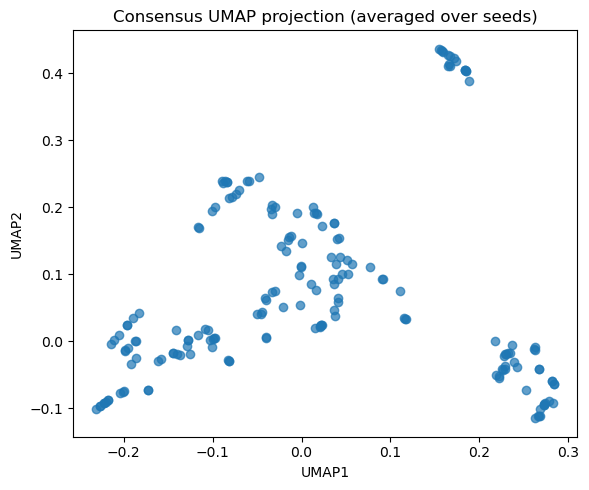

In [12]:
# Warning suppression for UMAP parallel processing.
import warnings
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.")

# Run UMAP with the best parameters and average embeddings over multiple runs.
n_runs = 100
umap_embeddings = []

for seed in range(n_runs):
    reducer_umap = umap.UMAP(
        n_components=2,
        n_neighbors=best_params['n_neighbors'],
        min_dist=best_params['min_dist'],
        repulsion_strength=best_params['repulsion_strength'],
        random_state=seed,
        n_jobs=-1
    )
    emb = reducer_umap.fit_transform(scaled_data_WT_pooled)
    umap_embeddings.append(emb)

# Align all embeddings to the first one using Procrustes
aligned_embeddings = [umap_embeddings[0]]
for emb in umap_embeddings[1:]:
    mtx1, mtx2, disparity = procrustes(umap_embeddings[0], emb)
    aligned_embeddings.append(mtx2)

# Average the aligned embeddings
consensus_embedding = np.mean(aligned_embeddings, axis=0)

plt.figure(figsize=(6,5))
plt.scatter(consensus_embedding[:,0], consensus_embedding[:,1], alpha=0.7)
plt.title('Consensus UMAP projection (averaged over seeds)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()

## 4 - Hierarchical clustering on UMAP
By performing hierarchical clustering (HC) on the UMAP embedding, we can identify clusters that may not be visible in the linear PCA projection. The resulting cluster labels are then projected back onto the PCA space to visualize how these non-linear clusters are distributed in the principal component axes.

### Cluster Number Selection Using Multiple Validation Metrics and Elbow Plot
This cell determines the optimal number of clusters for hierarchical clustering on the consensus UMAP embedding. It evaluates clustering quality across a range of cluster numbers (2–10) using three different metrics: Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index. For each metric, the optimal cluster number is identified and visualized in separate plots.   
Additionally, an elbow plot is generated using KMeans inertia, with a mono-exponential fit to help identify the "elbow" point.  
The final number of clusters (n_clust) is set to the value that maximizes the Silhouette Score, and this value is printed for use in subsequent analyses.  
  
  The silhouette score is optimal because it balances both cluster cohesion and separation.  

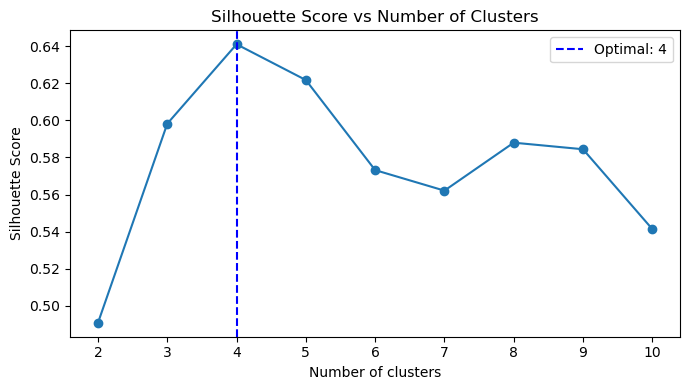

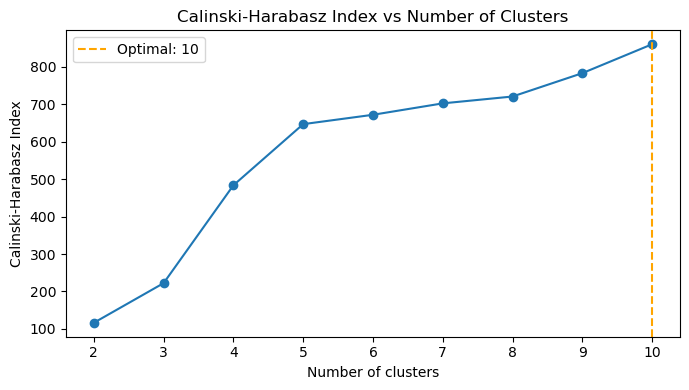

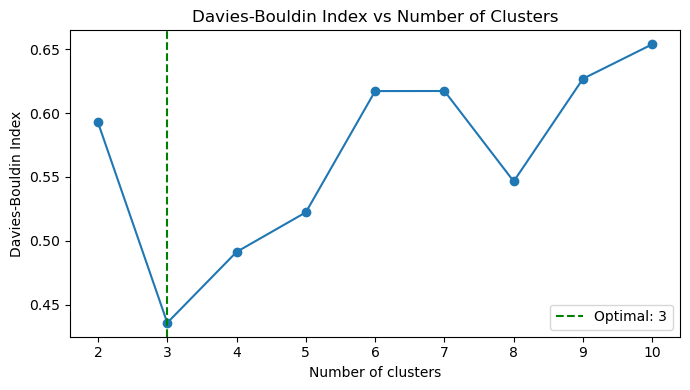

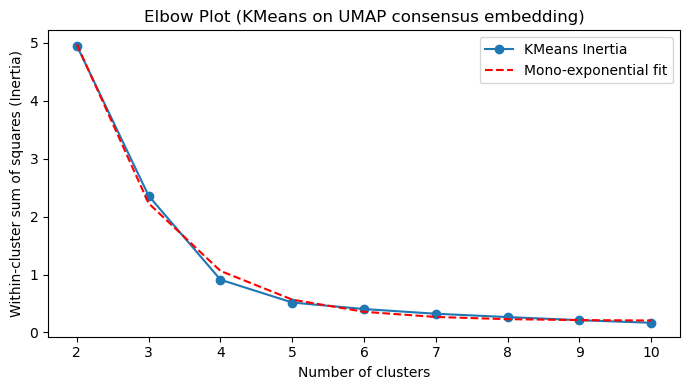

Silhouette score has been choosen, n_clust set to: 5


In [13]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# Cluster number selection using multiple validation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Range of cluster numbers to test
cluster_range = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_scores = []

# Use hierarchical clustering (Ward) on UMAP embedding for validation
Z_umap = linkage(consensus_embedding, method='ward')

for n_clusters in cluster_range:
    labels = fcluster(Z_umap, n_clusters, criterion='maxclust')
    silhouette_scores.append(silhouette_score(consensus_embedding, labels))
    calinski_scores.append(calinski_harabasz_score(consensus_embedding, labels))
    davies_scores.append(davies_bouldin_score(consensus_embedding, labels))

# Find optimal number of clusters for each metric
optimal_silhouette = cluster_range[np.argmax(silhouette_scores)]
optimal_calinski = cluster_range[np.argmax(calinski_scores)]
optimal_davies = cluster_range[np.argmin(davies_scores)]

# Plot for Silhouette Score
plt.figure(figsize=(7,4))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.axvline(optimal_silhouette, color='blue', linestyle='--', label=f'Optimal: {optimal_silhouette}')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Plot for Calinski-Harabasz Index
plt.figure(figsize=(7,4))
plt.plot(cluster_range, calinski_scores, marker='o')
plt.axvline(optimal_calinski, color='orange', linestyle='--', label=f'Optimal: {optimal_calinski}')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Plot for Davies-Bouldin Index
plt.figure(figsize=(7,4))
plt.plot(cluster_range, davies_scores, marker='o')
plt.axvline(optimal_davies, color='green', linestyle='--', label=f'Optimal: {optimal_davies}')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Elbow plot using within-cluster sum of squares (inertia) from KMeans
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit

inertias = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(consensus_embedding)
    inertias.append(kmeans.inertia_)

# Fit a mono-exponential decay to the inertia curve
def mono_exp(x, a, b, c):
    return a * np.exp(-b * x) + c

popt, _ = curve_fit(mono_exp, np.array(list(cluster_range)), inertias, maxfev=10000)

plt.figure(figsize=(7,4))
plt.plot(cluster_range, inertias, marker='o', label='KMeans Inertia')
plt.plot(cluster_range, mono_exp(np.array(list(cluster_range)), *popt), 'r--', label='Mono-exponential fit')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Elbow Plot (KMeans on UMAP consensus embedding)')
plt.legend()
plt.tight_layout()
plt.show()

# Set n_clust to the optimal silhouette value (or choose as needed)
#n_clust = optimal_silhouette
n_clust = 5  # Example value, replace with your choice based on the plots
print(f"Silhouette score has been choosen, n_clust set to: {n_clust}")

### Method selection

Different hierarchical clustering (HC) methods, such as 'ward', 'average', and 'complete', use different strategies to define the distance between clusters. Testing several methods allows us to see which one best separates the data into meaningful groups. The best method is the one that produces clusters that are most consistent with the biological or experimental structure of the data, and that are visually well separated in both the UMAP and PCA projections.  
Here 'ward' seems to give the best clustering, with cluster that are less mixted with their neighbor.

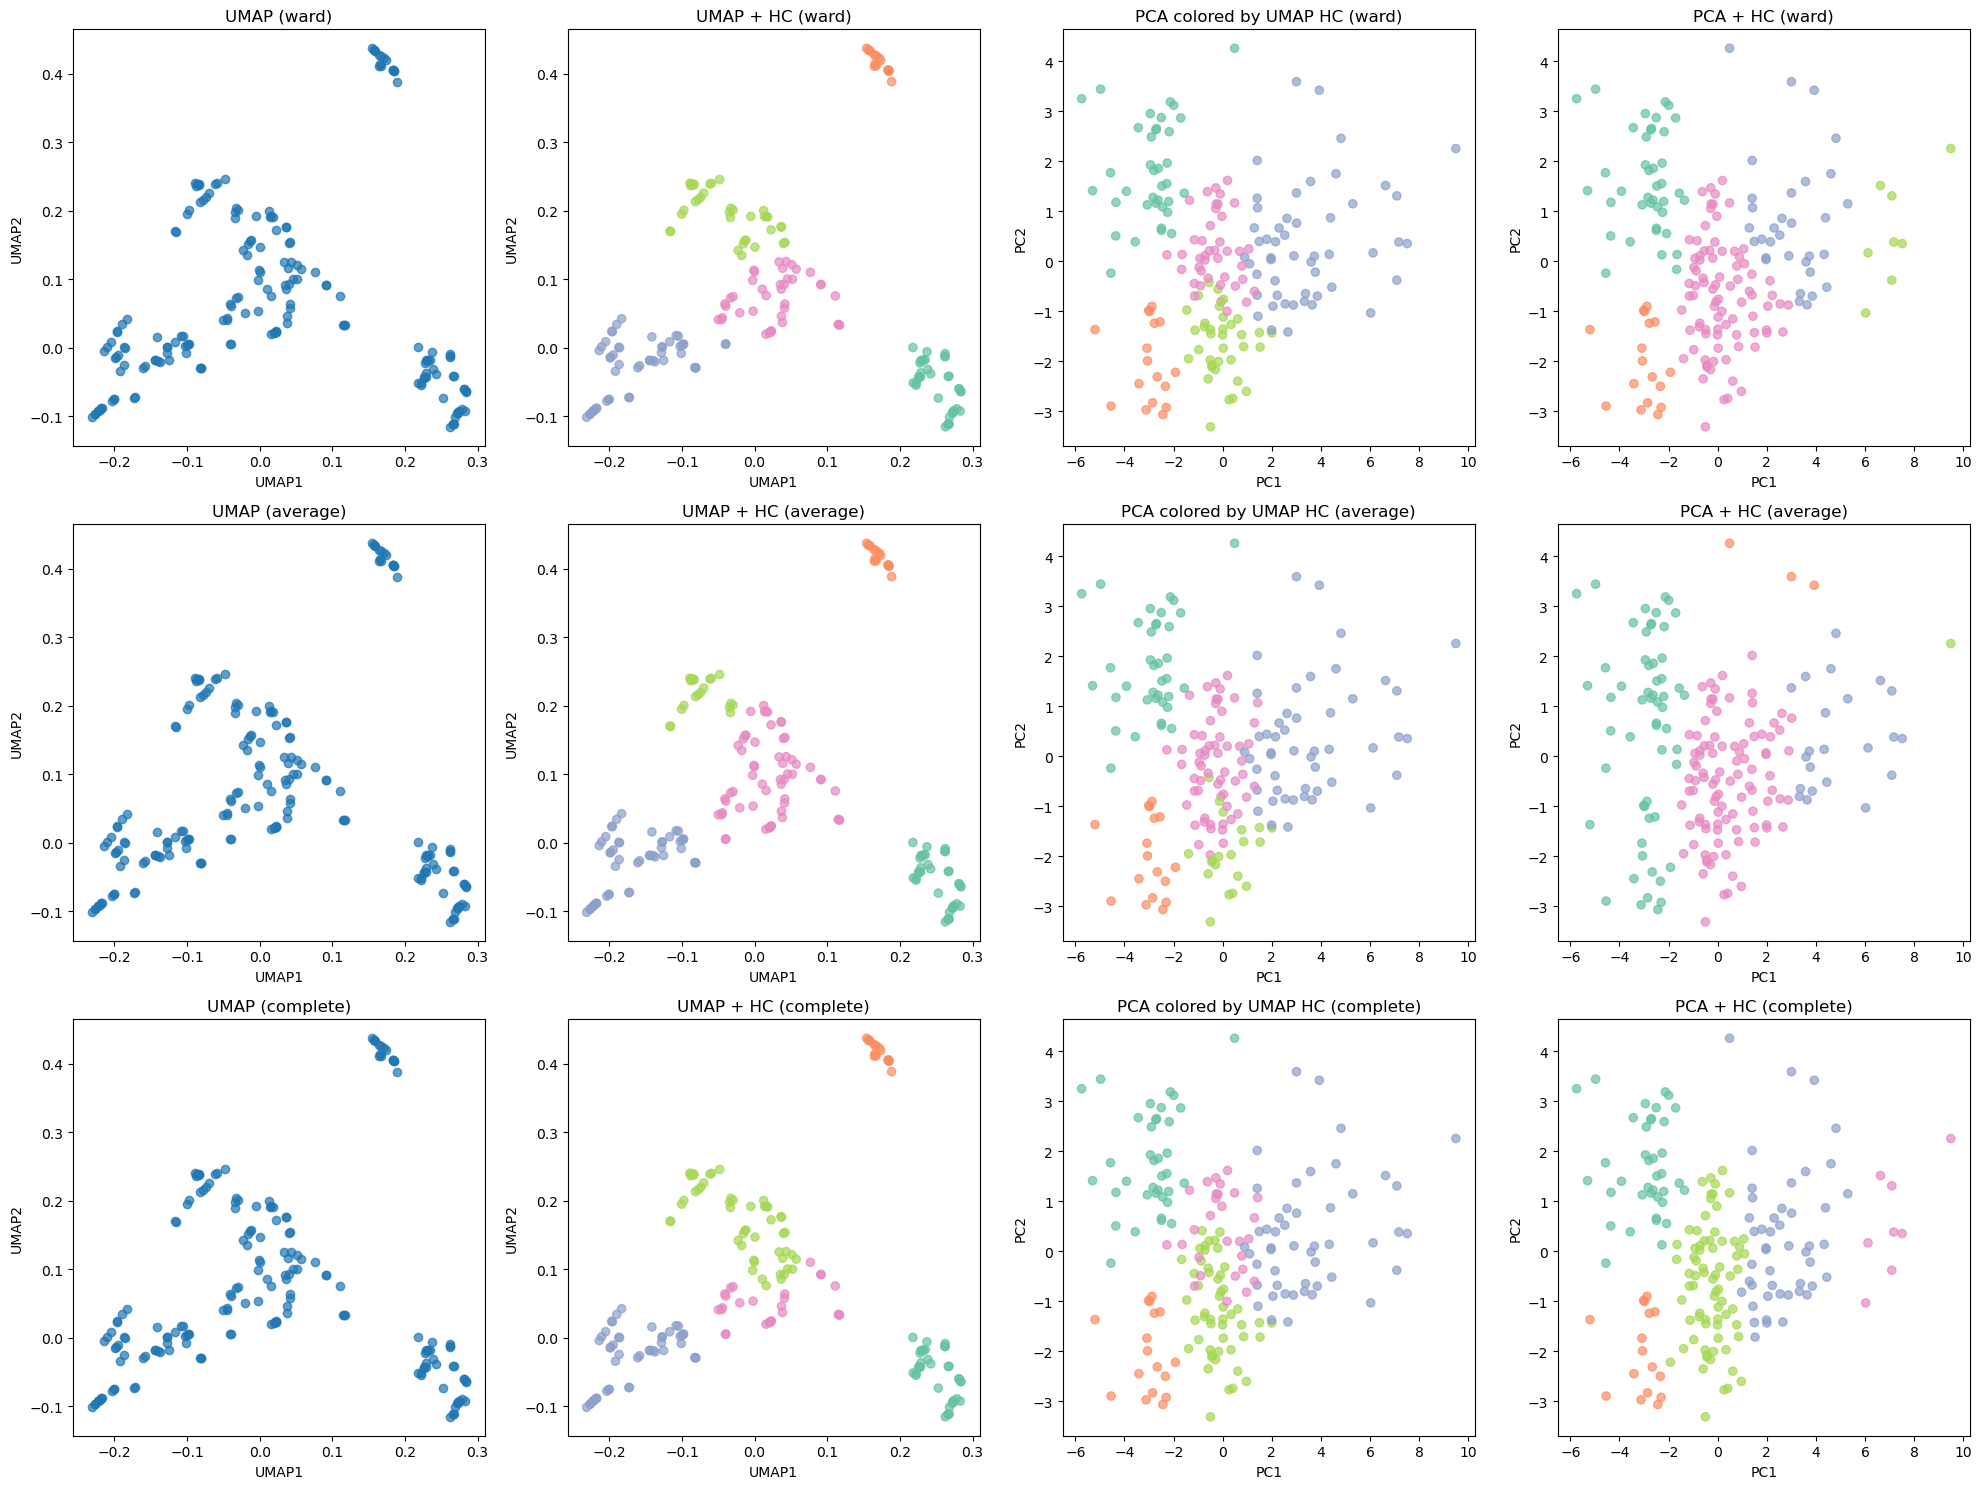

In [14]:
hc_methods = ['ward', 'average', 'complete']
fig, axes = plt.subplots(len(hc_methods), 4, figsize=(20, 5 * len(hc_methods)))
cmap = cm.get_cmap('Set2')

# Use the first method (ward) as reference for consistent colors
reference_method = hc_methods[0]
Z_ref = linkage(consensus_embedding, method=reference_method)
reference_labels = fcluster(Z_ref, n_clust, criterion='maxclust')

for i, method in enumerate(hc_methods):
    # UMAP HC
    Z_umap = linkage(consensus_embedding, method=method)
    hc_labels_umap = fcluster(Z_umap, n_clust, criterion='maxclust')
    
    # Align to reference if not the first method
    if i > 0:
        conf = confusion_matrix(reference_labels, hc_labels_umap)
        row_ind, col_ind = linear_sum_assignment(-conf)
        label_map = {col+1: row+1 for row, col in zip(row_ind, col_ind)}
        hc_labels_umap = np.array([label_map[x] for x in hc_labels_umap])

    # PCA HC
    Z_pca = linkage(transformed_data_WT_pooled, method=method)
    hc_labels_pca = fcluster(Z_pca, n_clust, criterion='maxclust')

    # Align PCA HC to the (now aligned) UMAP HC
    conf = confusion_matrix(hc_labels_umap, hc_labels_pca)
    row_ind, col_ind = linear_sum_assignment(-conf)
    label_map = {col+1: row+1 for row, col in zip(row_ind, col_ind)}
    hc_labels_pca_aligned = np.array([label_map[x] for x in hc_labels_pca])

    # Colors for clusters (now consistent across methods)
    colors_umap = [cmap(l-1) for l in hc_labels_umap]
    colors_pca_hc = [cmap(l-1) for l in hc_labels_pca_aligned]

    # UMAP scatter
    ax_umap = axes[i, 0]
    ax_umap.scatter(consensus_embedding[:, 0], consensus_embedding[:, 1], alpha=0.7)
    ax_umap.set_title(f'UMAP ({method})')
    ax_umap.set_xlabel('UMAP1')
    ax_umap.set_ylabel('UMAP2')

    # UMAP + HC scatter
    ax_umap_hc = axes[i, 1]
    ax_umap_hc.scatter(consensus_embedding[:, 0], consensus_embedding[:, 1], c=colors_umap, alpha=0.7)
    ax_umap_hc.set_title(f'UMAP + HC ({method})')
    ax_umap_hc.set_xlabel('UMAP1')
    ax_umap_hc.set_ylabel('UMAP2')

    # PCA with UMAP HC labels
    ax_pca_hc = axes[i, 2]
    ax_pca_hc.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], c=colors_umap, alpha=0.7)
    ax_pca_hc.set_title(f'PCA colored by UMAP HC ({method})')
    ax_pca_hc.set_xlabel('PC1')
    ax_pca_hc.set_ylabel('PC2')

    # PCA with PCA HC labels (aligned)
    ax_pca_hc2 = axes[i, 3]
    ax_pca_hc2.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], c=colors_pca_hc, alpha=0.7)
    ax_pca_hc2.set_title(f'PCA + HC ({method})')
    ax_pca_hc2.set_xlabel('PC1')
    ax_pca_hc2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### PCA + UMAP based HC + 95% confidence ellipse
Ellipse represent 95% confidence. A chi-square distribution with 2 degrees of freedom is used.

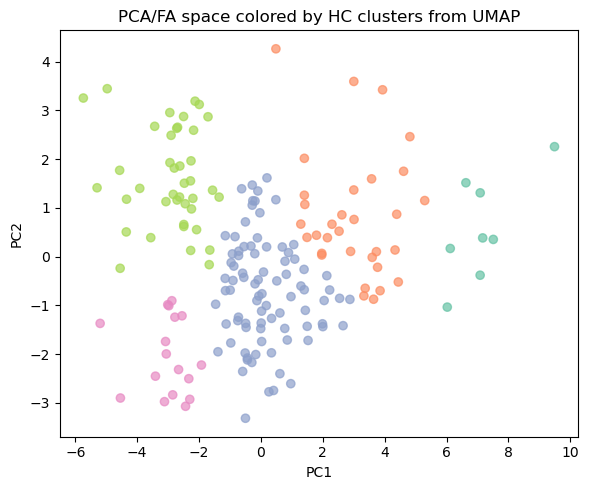

In [15]:
# Perform hierarchical clustering on UMAP embedding
Z_pca = linkage(transformed_data_WT_pooled, method='ward')
hc_labels_umap = fcluster(Z_pca, n_clust, criterion='maxclust')
#Z_pca = linkage(transformed_data_WT_pooled, method='ward')
#hc_labels_pca = fcluster(Z_pca, n_clust, criterion='maxclust')

# Import again the pooled data for WT and add HC labels 
df_WT_poolclust  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\DATA_Anthime.xlsx', sheet_name="WT_pooled")
df_WT_poolclust['HC_UMAP'] = hc_labels_umap

# Use consistent colormap
cmap = cm.get_cmap('Set2')
colors_umap = [cmap(l-1) for l in hc_labels_umap]

# Project HC cluster labels onto PCA/FA space
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], 
                    c=colors_umap, alpha=0.7)

def draw_ellipse(position, covariance, ax, **kwargs):
    """Draw confidence ellipse for cluster visualization"""
    if covariance.shape == (2, 2):
        # Critical value for 95% confidence with 2 degrees of freedom
        chi2_val = chi2.ppf(0.95, df=2)
        # Singular value decomposition of covariance matrix
        U, s, _ = np.linalg.svd(covariance)
        # Rotation angle of the ellipse
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        # Width and height of the ellipse (principal axes)
        width, height = 2 * np.sqrt(chi2_val * s)
    else:
        # 1D case (shouldn't happen with PC1 and PC2)
        angle = 0
        chi2_val = chi2.ppf(0.95, df=1)
        width, height = 2 * np.sqrt(chi2_val * covariance), 2 * np.sqrt(chi2_val * covariance)
    
    ellipse = Ellipse(position, width, height, angle, **kwargs)
    ax.add_patch(ellipse)

# Add confidence ellipses for each cluster
for cluster_id in range(1, n_clust + 1):
    # Get points belonging to this cluster
    cluster_mask = hc_labels_umap == cluster_id
    cluster_points = transformed_data_WT_pooled[cluster_mask]
    
    if len(cluster_points) > 2:  # Need at least 3 points for covariance
        # Calculate cluster center and covariance
        center = np.mean(cluster_points, axis=0)
        covariance = np.cov(cluster_points.T)
        
        # Draw 95% confidence ellipse
        #draw_ellipse(center, covariance, ax, 
                  #  facecolor=cmap(cluster_id-1), alpha=0.2, 
                  #  edgecolor=cmap(cluster_id-1), linewidth=2)

ax.set_title('PCA/FA space colored by HC clusters from UMAP')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()



plt.savefig(os.path.join(output_dir, "PCA_pooled.pdf"))

### Dendrogram

A dendrogram is plotted here to visualize the hierarchical relationships between samples based on their similarity in the consensus UMAP embedding. This tree-like diagram allows us to see how clusters are formed at different levels of similarity, identify distinct groups, and assess the structure and separation of clusters. It provides an intuitive way to explore the results of hierarchical clustering and supports the selection of cluster boundaries for downstream analysis.

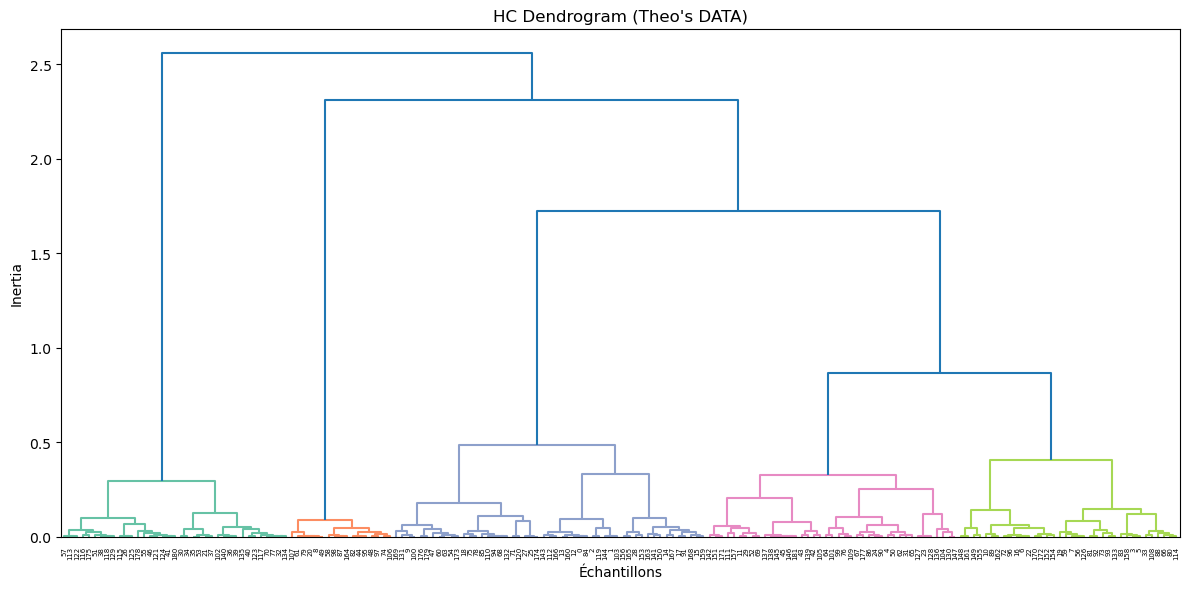

In [16]:
# Use the same colormap and number of clusters as before
cmap = cm.get_cmap('Set2')
hex_colors = [to_hex(cmap(i)) for i in range(n_clust)]
set_link_color_palette(hex_colors)

plt.figure(figsize=(12, 6))
dendrogram(Z_ref, color_threshold=Z_ref[-n_clust+1, 2], labels=transformed_WT_pooled.index.to_list(), leaf_rotation=90, )
plt.title("HC Dendrogram (Theo's DATA)")
plt.xlabel("Échantillons")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "HC_Dendrogram.pdf"))

### Biplot PCA
A biplot is used here to visualize both the samples and the variable loadings in the principal component space. This allows us to interpret how each original feature contributes to the first two principal components and to see the relationships between variables and samples simultaneously. By plotting the variable vectors, we can identify which features are most influential in separating the data, and how clusters or trends in the data relate to specific experimental measurements. This enhances the interpretability of the PCA results and helps link biological meaning to the observed patterns.


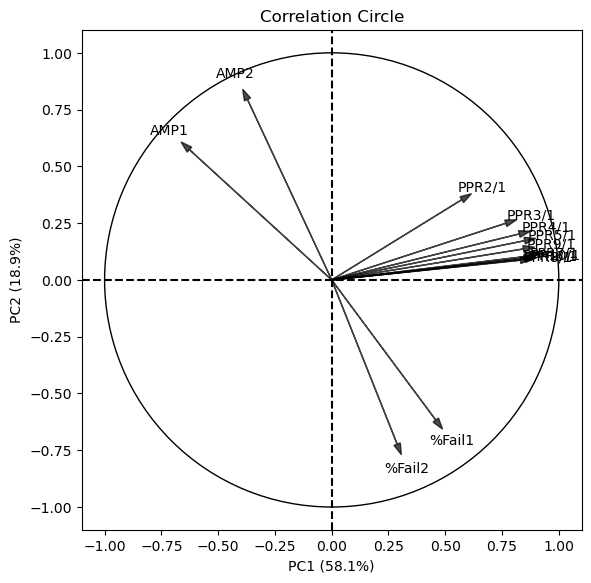

In [17]:
# PCA biplot: Visualize variable contributions to PC1 and PC2
# This uses the PCA object 'reducer' and its components_
# Update biplot to use correlation coefficients instead of loadings
# Get correlation coefficients between PCs and original variables
corr_coef = coeff_corr.T.values
scaling_factor = 1
corr_coef_scaled = corr_coef * scaling_factor

# Create the circle for correlation biplot
circle = plt.Circle((0, 0), 1, color='black', fill=False)
plt.figure(figsize=(6,6))
plt.axhline(0, color='black', linestyle='dashed')
plt.axvline(0, color='black', linestyle='dashed')
plt.gca().add_artist(circle)

# Plot correlation vectors
for i, var in enumerate(df_WT_pooled.columns):
    plt.arrow(0, 0, corr_coef_scaled[i, 0], corr_coef_scaled[i, 1],
              color='black', alpha=0.7, head_width=0.03, head_length=0.05, length_includes_head=True)
    plt.text(corr_coef_scaled[i, 0]*1.08, corr_coef_scaled[i, 1]*1.08, var, ha='center', va='center')

plt.xlabel(f"PC1 ({reducer_PCA.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({reducer_PCA.explained_variance_ratio_[1]*100:.1f}%)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.title('Correlation Circle')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "correlation_circle.pdf"))
plt.show()

## 5 - Average profile by classes

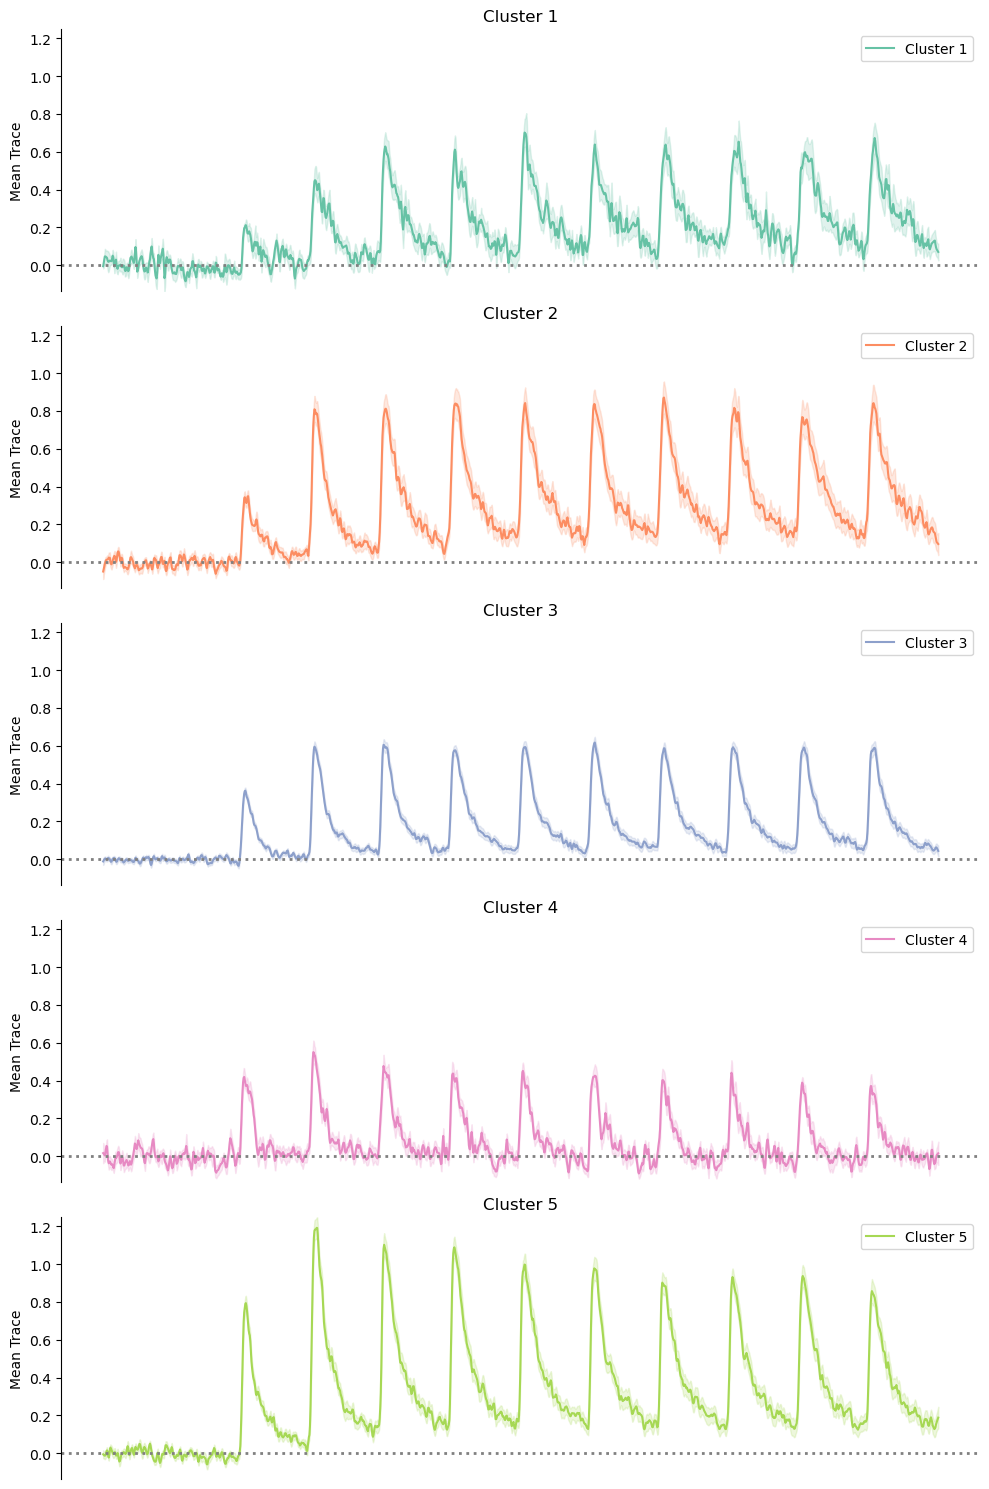

In [18]:
test  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=3)

# Extract time from the first column (ignoring the first row if it's an ID)
time = test.iloc[1:, 0].values
trace_ids = test.columns[1:]

# Associate each ID to its cluster via df_WT_poolclust
id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))
clusters = sorted(set(id_to_cluster.values()))
cmap = cm.get_cmap('Set2')

# Calculate global y-axis limits across all clusters
all_mean_traces = []
all_sem_traces = []
for cluster in clusters:
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        all_mean_traces.extend(mean_trace)
        all_sem_traces.extend(sem_trace)

# Calculate global y-limits
global_min = np.min(np.array(all_mean_traces) - np.array(all_sem_traces))
global_max = np.max(np.array(all_mean_traces) + np.array(all_sem_traces))

# Create a figure with one subplot per cluster
fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 3*len(clusters)), sharex=True)

# Verification of IDs associated with each cluster
for cluster in sorted(set(id_to_cluster.values())):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    #print(f"Cluster {cluster}: {cluster_ids}")

plotted = False
for idx, cluster in enumerate(clusters):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        color = cmap(idx)
        axes[idx].plot(time, mean_trace, color=color, label=f'Cluster {cluster}')
        axes[idx].fill_between(time, mean_trace-sem_trace, mean_trace+sem_trace, color=color, alpha=0.2)
        axes[idx].axhline(0, color='gray', linestyle='dotted', linewidth=2)
        axes[idx].set_ylabel('Mean Trace')
        axes[idx].legend(loc='upper right')
        axes[idx].set_title(f'Cluster {cluster}')
        
        # Set consistent y-axis limits for all subplots
        axes[idx].set_ylim(global_min, global_max)
        
        # Remove frame and x-axis
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)
        axes[idx].spines['bottom'].set_visible(False)
        axes[idx].get_xaxis().set_visible(False)
        
        plotted = True
    else:
        axes[idx].set_visible(False)

plt.tight_layout()
if plotted:
    plt.show()
else:
    print('No traces found for any cluster.')

## 6 - Release properties
Here are ploted the different properties of each classes of boutons.
### PPR profiles

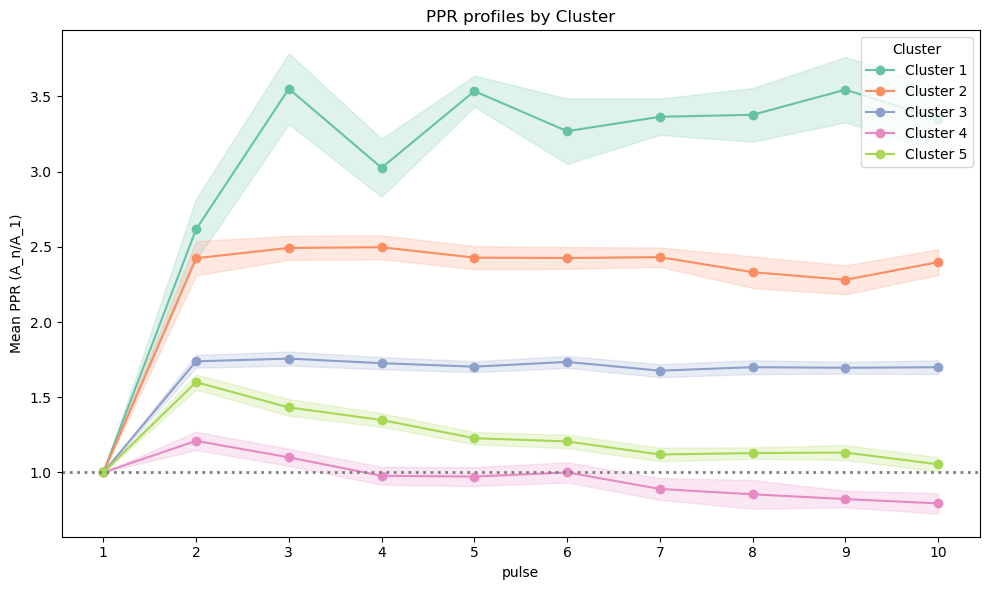

In [19]:
# Plot PPR profiles for each cluster with SEM and custom x-axis, using consistent Set2 colors
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
cmap = cm.get_cmap('Set2')
plt.figure(figsize=(10, 6))
for idx, cluster in enumerate(clusters):
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(idx)
    plt.plot(x_pulses, means, marker='o', label=f'Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles by Cluster')
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_PPR_profiles.pdf"))
plt.show()

### PPR2 (A2/A1)

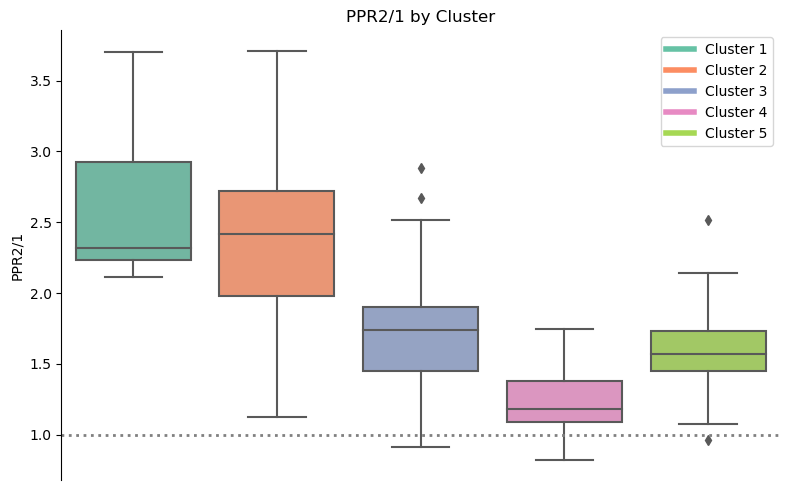

In [20]:
# Create a boxplot for PPR2/1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR2/1', data=df_WT_poolclust, palette='Set2')
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR2/1')
plt.title('PPR2/1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
# Legend with cluster labels
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_PPR2_1.pdf"))

### PPR3 (A3/A1)

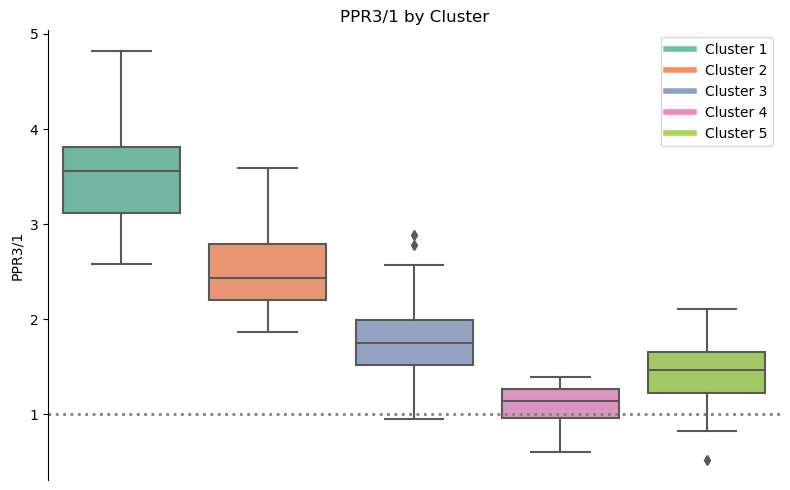

In [21]:
# Create a boxplot for PPR3/1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR3/1', data=df_WT_poolclust, palette='Set2')
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR3/1')
plt.title('PPR3/1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_PPR3_1.pdf"))


### AMP1

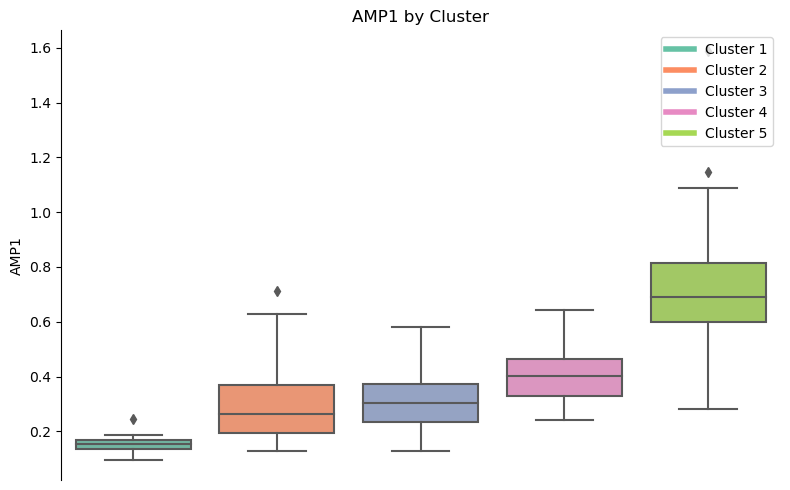

In [22]:
# Create a boxplot for AMP1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='AMP1', data=df_WT_poolclust, palette='Set2')
plt.ylabel('AMP1')
plt.title('AMP1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_AMP1.pdf"))

### %Fail1

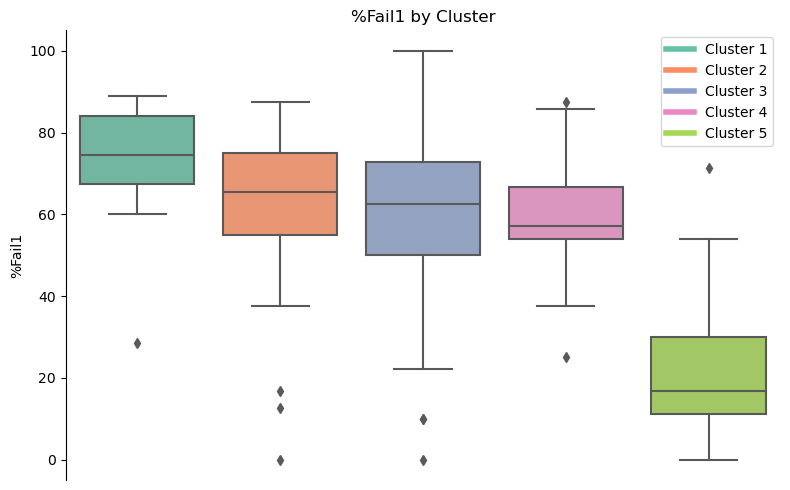

In [23]:
# Create a boxplot for %Fail1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='%Fail1', data=df_WT_poolclust, palette='Set2')
plt.ylabel('%Fail1')
plt.title('%Fail1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_clust_Fail1.pdf"))

# Figure 2 : SynII
## 1 - Projection des données SynII sur la PCA

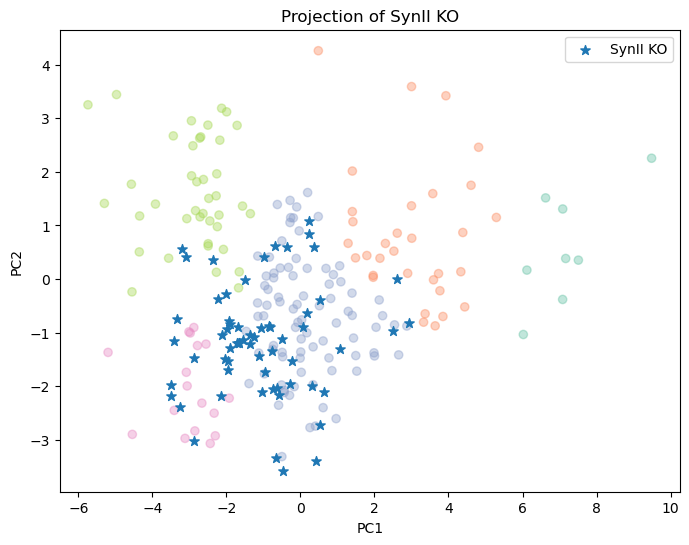

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.4)
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],marker='*', s=50, label='SynII KO')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection of SynII KO')
plt.legend()
plt.show
plt.savefig(os.path.join(output_dir, "PCA_synII.pdf"))

# 2 - Proportion de SynII dans les clusters WT
## Proportion of SynII in WT Clusters

This analysis explores the distribution of SynII knockout data points across the clusters previously identified in wild-type (WT) samples. 

The visualization in the previous cell reveals that SynII knockout boutons have a distinct distribution pattern among the five functional classes identified in WT boutons. This suggests that the absence of Synapsin II alters specific aspects of synaptic transmission, potentially affecting some functional clusters more than others.

The bar chart compares the percentage of boutons belonging to each cluster between WT and SynII samples, highlighting shifts in the functional profile caused by the Synapsin II knockout. This comparison helps identify which specific functional classes of synaptic transmission are most affected by the loss of Synapsin II.

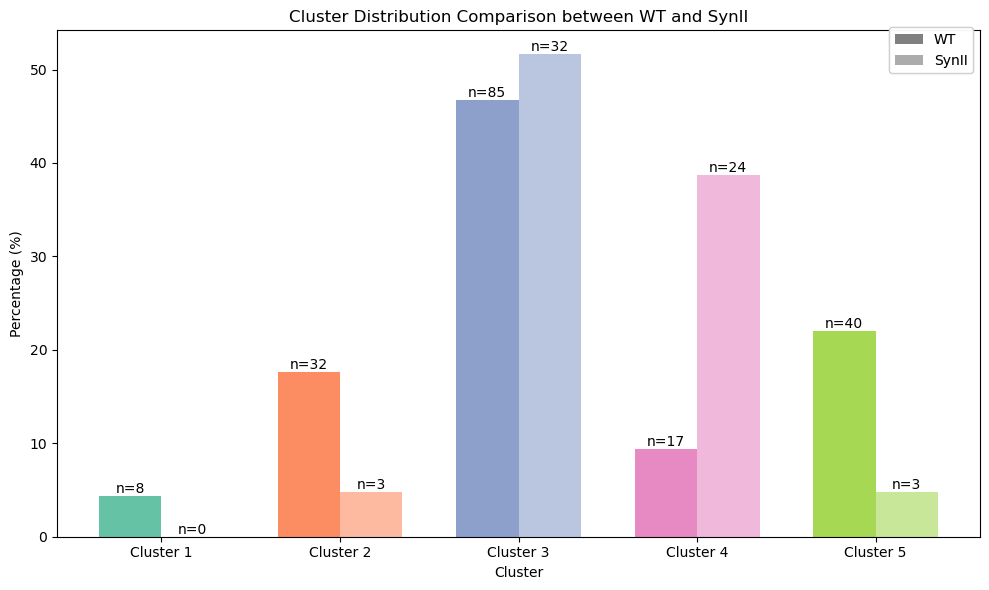

Cluster distribution in WT samples:
Cluster 1: 4.4% (n=8)
Cluster 2: 17.6% (n=32)
Cluster 3: 46.7% (n=85)
Cluster 4: 9.3% (n=17)
Cluster 5: 22.0% (n=40)

Cluster distribution in SynII samples:
Cluster 1: 0.0% (n=0)
Cluster 2: 4.8% (n=3)
Cluster 3: 51.6% (n=32)
Cluster 4: 38.7% (n=24)
Cluster 5: 4.8% (n=3)


In [44]:
# Function to assign new data to existing clusters based on proximity to centroids
def assign_clusters_hcpc(X_ref_scaled, clusters_ref, X_target_scaled):
    # Calculate centroids of reference clusters
    centroids = np.array([X_ref_scaled[clusters_ref == i].mean(axis=0) for i in np.unique(clusters_ref)])
    assigned = []
    for x in X_target_scaled:
        # Find closest centroid
        dist = np.linalg.norm(centroids - x, axis=1)
        assigned.append(np.argmin(dist) + 1)  # +1 because clusters are 1-indexed
    return np.array(assigned)

# Assign SynII data to WT clusters
clusters_SynII = assign_clusters_hcpc(transformed_data_WT_pooled, hc_labels_umap, transformed_data_SynII)

# Calculate counts and percentages for both datasets
wt_counts = pd.Series(hc_labels_umap).value_counts().sort_index()
wt_counts = pd.DataFrame({
    'Cluster': wt_counts.index,
    'Count': wt_counts.values,
    'Percentage': 100 * wt_counts.values / len(hc_labels_umap),
    'Dataset': 'WT'
})

# Ensure all clusters are represented in synii_counts
all_clusters = range(1, n_clust + 1)
synii_counts_series = pd.Series(clusters_SynII).value_counts()
synii_counts = pd.DataFrame({
    'Cluster': all_clusters,
    'Count': [synii_counts_series.get(c, 0) for c in all_clusters],
    'Percentage': [100 * synii_counts_series.get(c, 0) / len(clusters_SynII) for c in all_clusters],
    'Dataset': 'SynII'
})
synii_counts = synii_counts.sort_values('Cluster').reset_index(drop=True)

# Create figure and axis objects
plt.figure(figsize=(10, 6))

# Create color palette for clusters using Set2
cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)
cluster_colors = [cmap(i) for i in range(n_clusters)]

# Setup for grouped bar plot
bar_width = 0.35
x = np.arange(n_clusters)

# Plot WT bars - solid colors
bars_wt = plt.bar(x - bar_width/2, wt_counts['Percentage'], bar_width,
                  label='WT', color=cluster_colors)

# Plot SynII bars - same colors but transparent
bars_synii = plt.bar(x + bar_width/2, synii_counts['Percentage'], bar_width,
                     label='SynII', color=cluster_colors, alpha=0.6)

# Add count labels on the bars
for bars, counts in [(bars_wt, wt_counts), (bars_synii, synii_counts)]:
    for bar, count in zip(bars, counts['Count']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                f'n={int(count)}',
                ha='center', va='bottom')

plt.title('Cluster Distribution Comparison between WT and SynII')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.xticks(x, [f'Cluster {i}' for i in wt_counts['Cluster']])

# Add dataset type legend
wt_patch = plt.Rectangle((0,0),1,1, fc='gray')
synii_patch = plt.Rectangle((0,0),1,1, fc='gray', alpha=0.6)
l1 = plt.legend([wt_patch, synii_patch], ['WT', 'SynII'], 
                loc='upper right', bbox_to_anchor=(1, 1.02))
plt.gca().add_artist(l1)


plt.tight_layout()
plt.savefig(os.path.join(output_dir, "WT_SynII_cluster_comparison.pdf"))
plt.show()

# Print the distribution summary
print("Cluster distribution in WT samples:")
for i, row in wt_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")

print("\nCluster distribution in SynII samples:")
for i, row in synii_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")


# Figure 3 : Diversité sur une même fibre
## 1 - Barplot of the proportion of PFs displaying 1 to 4 classes of boutons

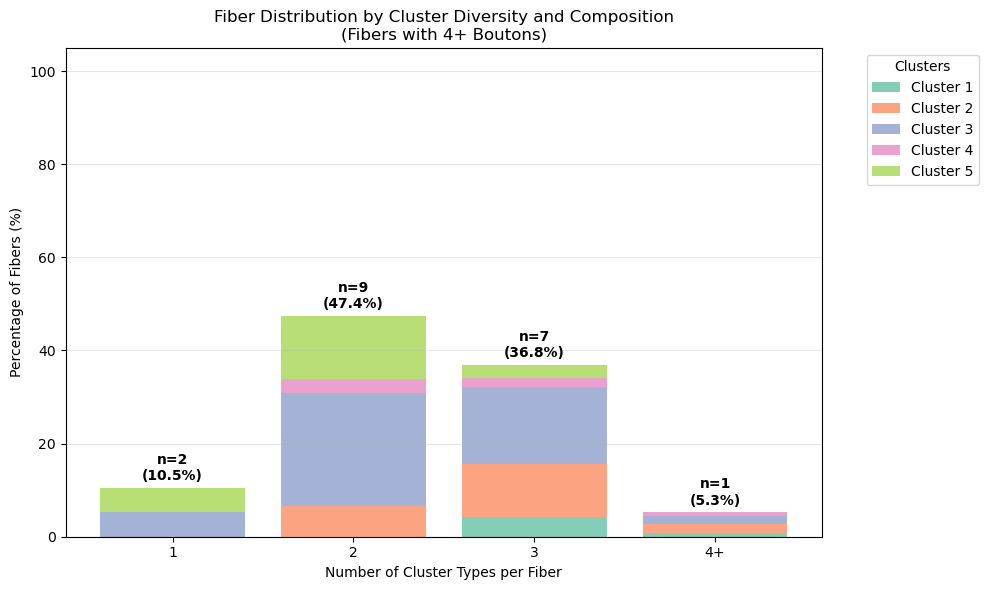

Fiber cluster diversity composition summary (fibers with 4+ boutons only):

Fibers with 1 cluster type(s): 2 fibers (10.5%)
  Cluster 3: 50.0% average proportion (1.0 fiber-equivalents)
  Cluster 5: 50.0% average proportion (1.0 fiber-equivalents)

Fibers with 2 cluster type(s): 9 fibers (47.4%)
  Cluster 2: 14.0% average proportion (1.3 fiber-equivalents)
  Cluster 3: 51.0% average proportion (4.6 fiber-equivalents)
  Cluster 4: 6.7% average proportion (0.6 fiber-equivalents)
  Cluster 5: 28.3% average proportion (2.5 fiber-equivalents)

Fibers with 3 cluster type(s): 7 fibers (36.8%)
  Cluster 1: 11.2% average proportion (0.8 fiber-equivalents)
  Cluster 2: 31.2% average proportion (2.2 fiber-equivalents)
  Cluster 3: 44.7% average proportion (3.1 fiber-equivalents)
  Cluster 4: 5.2% average proportion (0.4 fiber-equivalents)
  Cluster 5: 7.6% average proportion (0.5 fiber-equivalents)

Fibers with 4+ cluster type(s): 1 fibers (5.3%)
  Cluster 1: 16.7% average proportion (0.2 fiber-e

In [52]:
# Extract fiber ID from the full ID (first 22 characters)
df_WT_poolclust['Fiber_ID'] = df_WT_poolclust['ID'].str[:22]

# Count total number of boutons per fiber
fiber_bouton_counts = df_WT_poolclust.groupby('Fiber_ID').size().reset_index(name='Bouton_Count')

# Filter to keep only fibers with 4 or more boutons
fibers_with_enough_boutons = fiber_bouton_counts[fiber_bouton_counts['Bouton_Count'] >= 4]['Fiber_ID'].tolist()
df_filtered = df_WT_poolclust[df_WT_poolclust['Fiber_ID'].isin(fibers_with_enough_boutons)]

# Count number of different clusters per fiber
fiber_cluster_diversity = df_filtered.groupby('Fiber_ID')['HC_UMAP'].nunique().reset_index()
fiber_cluster_diversity.columns = ['Fiber_ID', 'Num_Cluster_Types']

# Add bouton count information
fiber_cluster_diversity = fiber_cluster_diversity.merge(
    fiber_bouton_counts, on='Fiber_ID', how='left'
)

# Categorize fibers by number of cluster types (cap at 4+)
fiber_cluster_diversity['Cluster_Diversity'] = fiber_cluster_diversity['Num_Cluster_Types'].apply(
    lambda x: f'{x}' if x <= 3 else '4+'
)

# Calculate cluster distribution for each diversity category
diversity_cluster_data = {}
for fiber_id in df_filtered['Fiber_ID'].unique():
    fiber_data = df_filtered[df_filtered['Fiber_ID'] == fiber_id]
    num_clusters = len(fiber_data['HC_UMAP'].unique())
    diversity_key = str(num_clusters) if num_clusters <= 3 else '4+'
    
    if diversity_key not in diversity_cluster_data:
        diversity_cluster_data[diversity_key] = []
    
    # Count clusters for this fiber
    cluster_counts = fiber_data['HC_UMAP'].value_counts()
    total_boutons = len(fiber_data)
    cluster_props = {cluster: count/total_boutons for cluster, count in cluster_counts.items()}
    diversity_cluster_data[diversity_key].append(cluster_props)

# Calculate average proportions and absolute counts for each cluster in each diversity category
diversity_order = ['1', '2', '3', '4+']
cmap = cm.get_cmap('Set2')
n_clusters_total = 5  # Total number of clusters

# Calculate mean proportions and fiber counts
diversity_means = {}
diversity_counts = {}
total_fibers = len(fiber_cluster_diversity)

for diversity in diversity_order:
    if diversity in diversity_cluster_data:
        diversity_counts[diversity] = len(diversity_cluster_data[diversity])
        cluster_means = {}
        for cluster in range(1, n_clusters_total + 1):
            proportions = [fiber_data.get(cluster, 0) for fiber_data in diversity_cluster_data[diversity]]
            cluster_means[cluster] = np.mean(proportions)
        diversity_means[diversity] = cluster_means
    else:
        diversity_counts[diversity] = 0
        diversity_means[diversity] = {cluster: 0 for cluster in range(1, n_clusters_total + 1)}

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

x_positions = np.arange(len(diversity_order))
bottom = np.zeros(len(diversity_order))

# Create stacked bars with cluster colors - height = percentage of fibers * proportion
for cluster in range(1, n_clusters_total + 1):
    # Calculate percentage values: (number of fibers / total fibers) * 100 * proportion of that cluster
    percentage_values = [(diversity_counts[div] / total_fibers) * 100 * diversity_means[div][cluster] for div in diversity_order]
    bars = ax.bar(x_positions, percentage_values, bottom=bottom, 
                  color=cmap(cluster-1), label=f'Cluster {cluster}', alpha=0.8)
    bottom += percentage_values

# Add count and percentage labels on top of bars
for i, (diversity, count) in enumerate(zip(diversity_order, [diversity_counts[d] for d in diversity_order])):
    percentage_total = (count / total_fibers) * 100
    ax.text(i, percentage_total + 1, f'n={count}\n({percentage_total:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Number of Cluster Types per Fiber')
ax.set_ylabel('Percentage of Fibers (%)')
ax.set_title('Fiber Distribution by Cluster Diversity and Composition\n(Fibers with 4+ Boutons)')
ax.set_xticks(x_positions)
ax.set_xticklabels(diversity_order)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Set y-axis to start at 0 and go to 100%
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fiber_cluster_diversity_composition_4plus_boutons.pdf"))
plt.show()

# Print detailed summary statistics
print("Fiber cluster diversity composition summary (fibers with 4+ boutons only):")
for diversity in diversity_order:
    if diversity in diversity_counts and diversity_counts[diversity] > 0:
        percentage_of_total = (diversity_counts[diversity] / total_fibers) * 100
        print(f"\nFibers with {diversity} cluster type(s): {diversity_counts[diversity]} fibers ({percentage_of_total:.1f}%)")
        for cluster in range(1, n_clusters_total + 1):
            prop = diversity_means[diversity][cluster]
            if prop > 0:
                absolute_count = diversity_counts[diversity] * prop
                print(f"  Cluster {cluster}: {prop:.1%} average proportion ({absolute_count:.1f} fiber-equivalents)")

print(f"\nTotal number of fibers analyzed: {total_fibers}")
print(f"(filtered from {len(fiber_bouton_counts)} total fibers)")

# Calculate average number of boutons per fiber in the filtered dataset
avg_boutons = fiber_cluster_diversity['Bouton_Count'].mean()
print(f"Average boutons per fiber in filtered dataset: {avg_boutons:.1f}")

# Print list of fibers with exactly 3 cluster types
fibers_with_3_clusters = fiber_cluster_diversity[fiber_cluster_diversity['Num_Cluster_Types'] == 3]['Fiber_ID'].tolist()
print(f"\nList of fibers with exactly 3 cluster types ({len(fibers_with_3_clusters)} fibers):")
for fiber_id in fibers_with_3_clusters:
    print(f"  {fiber_id}")

## 2 - Potential SynII fibers vs potential non-SynII fibers

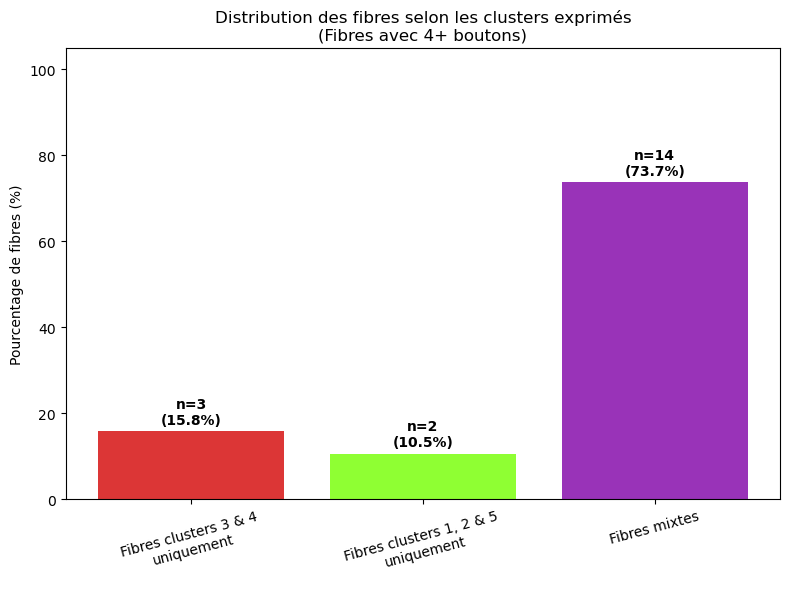

Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):
- Fibres exprimant uniquement les clusters 3 et/ou 4: 3 fibres (15.8%)
- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: 2 fibres (10.5%)
- Fibres mixtes (combinaison des deux groupes): 14 fibres (73.7%)
- Total: 19 fibres (avec 4+ boutons)

Exemples de fibres mixtes (si il y en a):
  241211_Fibre1_PortionA: clusters [2, 3, 5]
  20190801_linescan1_20H: clusters [1, 2, 3]
  241212_Fibre1_PortionB: clusters [1, 2, 3]
  20220426_linescan1_20H: clusters [2, 3]
  20210310_linescan4_20H: clusters [2, 3]
  ... et 9 autres fibres mixtes

Détail des fibres clusters 3 & 4 uniquement:
  20210304_linescan2_20H: clusters [3]
  20210308_linescan2_20H: clusters [3, 4]
  20210310_linescan1_20H: clusters [3, 4]

Détail des fibres clusters 1, 2 & 5 uniquement:
  20210128_linescan4_20H: clusters [5]
  20220414_linescan1_20H: clusters [2, 5]


In [60]:
# Classification des fibres selon les clusters exprimés
# Utiliser seulement les fibres avec 4+ boutons (comme dans l'analyse précédente)
fibers_clusters = df_filtered.groupby('Fiber_ID')['HC_UMAP'].apply(lambda x: set(x.unique()))

# Fibres n'exprimant QUE les clusters 3 et/ou 4 (aucun autre cluster)
fibers_only_3_4 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({3, 4}) and len(s) > 0)]

# Fibres n'exprimant QUE les clusters 1, 2 et/ou 5 (aucun autre cluster)
fibers_only_1_2_5 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({1, 2, 5}) and len(s) > 0)]

# Comptage
count_only_3_4 = len(fibers_only_3_4)
count_only_1_2_5 = len(fibers_only_1_2_5)

# Fibres mixtes (contenant des clusters des deux groupes)
all_fiber_ids = set(fibers_clusters.index)
exclusive_fiber_ids = set(fibers_only_3_4.index) | set(fibers_only_1_2_5.index)
mixed_fibers = all_fiber_ids - exclusive_fiber_ids
count_mixed = len(mixed_fibers)

# Calcul des pourcentages
total_fibers_filtered = len(fibers_clusters)
percentage_3_4 = (count_only_3_4 / total_fibers_filtered) * 100
percentage_1_2_5 = (count_only_1_2_5 / total_fibers_filtered) * 100
percentage_mixed = (count_mixed / total_fibers_filtered) * 100

# Création de l'histogramme avec 3 catégories
labels = ['Fibres clusters 3 & 4\nuniquement', 'Fibres clusters 1, 2 & 5\nuniquement', 'Fibres mixtes']
counts = [count_only_3_4, count_only_1_2_5, count_mixed]
percentages = [percentage_3_4, percentage_1_2_5, percentage_mixed]


plt.figure(figsize=(8,6))
bars = plt.bar(labels, percentages, color=["#d40404", "#73ff00", "#8000a7"], alpha=0.8)
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, pct + 1, 
             f'n={count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Pourcentage de fibres (%)')
plt.title('Distribution des fibres selon les clusters exprimés\n(Fibres avec 4+ boutons)')
plt.xticks(rotation=15)
plt.ylim(0, 105)  # Limiter l'axe Y de 0 à 105%
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fiber_distribution_by_cluster_type.pdf"))
plt.show()

# Affichage des statistiques détaillées
print(f"Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):")
print(f"- Fibres exprimant uniquement les clusters 3 et/ou 4: {count_only_3_4} fibres ({percentage_3_4:.1f}%)")
print(f"- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: {count_only_1_2_5} fibres ({percentage_1_2_5:.1f}%)")
print(f"- Fibres mixtes (combinaison des deux groupes): {count_mixed} fibres ({percentage_mixed:.1f}%)")
print(f"- Total: {total_fibers_filtered} fibres (avec 4+ boutons)")

# Vérification que toutes les fibres sont bien comptées
assert count_only_3_4 + count_only_1_2_5 + count_mixed == total_fibers_filtered, "Erreur: toutes les fibres ne sont pas comptées"

print(f"\nExemples de fibres mixtes (si il y en a):")
if count_mixed > 0:
    for i, fiber_id in enumerate(list(mixed_fibers)[:5]):  # Afficher les 5 premières
        clusters_in_fiber = list(fibers_clusters[fiber_id])
        print(f"  {fiber_id}: clusters {clusters_in_fiber}")
    if count_mixed > 5:
        print(f"  ... et {count_mixed - 5} autres fibres mixtes")
else:
    print("  Aucune fibre mixte détectée")

# Affichage détaillé des fibres de chaque catégorie
print(f"\nDétail des fibres clusters 3 & 4 uniquement:")
for fiber_id in fibers_only_3_4.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

print(f"\nDétail des fibres clusters 1, 2 & 5 uniquement:")
for fiber_id in fibers_only_1_2_5.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")